## 🛠️Data Engineering & Wrangling Decisions

To prepare the Olist dataset for analytical modeling, the team implemented a robust data processing and optimization pipeline:

* **Type Standardization:** Fixed critical schema mismatches by converting inconsistent float identifiers (e.g., transaction and delivery keys) into standardized, clean strings to ensure seamless multi-table joins.
* **Predictive Feature Engineering:** Created new continuous features to capture customer friction, such as a *delivery variance metric* that calculates the exact delta between estimated and actual delivery dates (negative values = early, positive values = late).
* **Cost-Optimized Threshold Tuning:** Intentionally adjusted the classification decision threshold down to **0.45** (instead of the default 0.5) to aggressively maximize **Recall** for the unsatisfied customer class. This ensures high-risk churning customers are caught and offered loyalty incentives, successfully minimizing the costly business risk of undetected customer churn.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

⏳ Lade und bereinige Daten aus der CSV...
Starte optimiertes Modell-Training mit 96359 Zeilen...
--- Start Modellauswertung (Direktvergleich) --- 

                Modell Accuracy Precision (Schlecht) Recall (Schlecht) F1-Score (Schlecht)
Logistische Regression   75.56%               41.67%            39.98%              40.81%
         Decision Tree   69.87%               33.28%            42.74%              37.42%
         Random Forest   69.72%               33.37%            43.80%              37.88%
------------------------------------------------------------

🏆 MODELL-EMPFEHLUNG & ENTSCHEIDUNG
Das beste Modell nach Gesamtgenauigkeit ist: Logistische Regression
Es erzielt eine Basis-Accuracy von: 75.56%
-> Daher wird die Logistische Regression für das finale Threshold-Tuning genutzt.
🔄 Berechne robuste Kreuzvalidierung für das finale Modell...

📊 FINALES OPTIMIERTES ML-MODELL ERGEBNIS
▶ Genutzter Algorithmus: Logistische Regression
▶ Gesamtgenauigkeit (Accuracy) nach Tuning: 79.

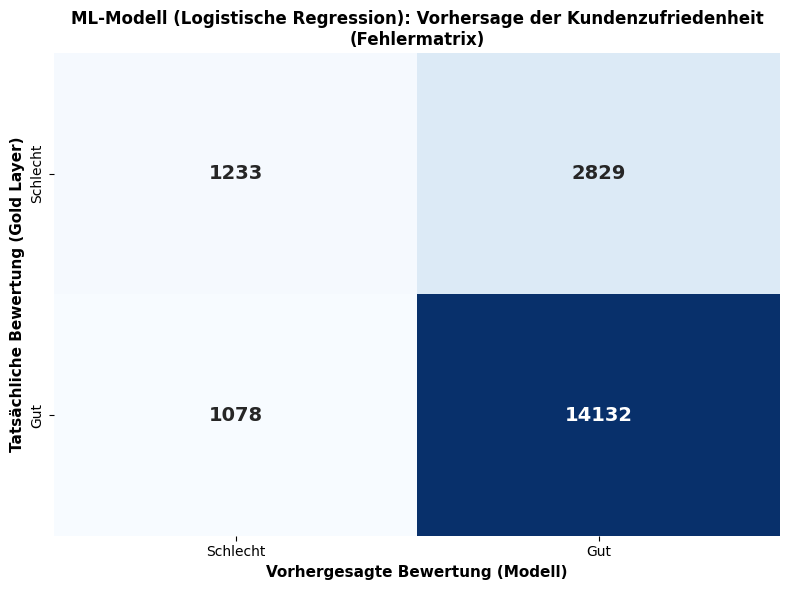

In [ ]:

print("⏳ Lade und bereinige Daten aus der CSV...")

df = pd.read_csv("ML_dataset.csv", sep=';', encoding="utf-8")
df.columns = df.columns.str.strip()

df['purchase_key_clean'] = pd.to_numeric(df['purchase_key'], errors='coerce').fillna(0).astype(int).astype(str)
df['delivered_key_clean'] = pd.to_numeric(df['delivered_key'], errors='coerce').fillna(0).astype(int).astype(str)
df['estimated_key_clean'] = pd.to_numeric(df['estimated_key'], errors='coerce').fillna(0).astype(int).astype(str)


df['purchase_date'] = pd.to_datetime(df['purchase_key_clean'], format='%Y%m%d', errors='coerce')
df['delivered_date'] = pd.to_datetime(df['delivered_key_clean'], format='%Y%m%d', errors='coerce')
df['estimated_delivery_date'] = pd.to_datetime(df['estimated_key_clean'], format='%Y%m%d', errors='coerce')


df = df.dropna(subset=['purchase_date', 'delivered_date', 'estimated_delivery_date'])

# ==========================================
# Converting into a 6 day week (Standard length of working week in brasil) 
# ==========================================
def net_working_days_6(start, end):
    total_days = (end - start).dt.days
    sundays = np.busday_count(
        start.dt.date.values.astype('datetime64[D]'),
        end.dt.date.values.astype('datetime64[D]'),
        weekmask='0000001' # excluding sundays
    )
    return np.maximum(0, total_days - sundays)

df['total_delivery_time'] = net_working_days_6(df['purchase_date'], df['delivered_date'])
df['is_late'] = np.where(df['delivered_date'] > df['estimated_delivery_date'], 1, 0)

# Removing outliers
df = df[df['total_delivery_time'] >= 0].copy()
# ==========================================
# Pipeline and feature engineering
# ==========================================
print(f"Starte optimiertes Modell-Training mit {len(df)} Zeilen...")



df['delivery_delay_days'] = (df['delivered_date'] - df['estimated_delivery_date']).dt.days


y = np.where(df['review_score'] >= 4.0, 1, 0)


NUM_FEATURES = ['total_delivery_time', 'is_late', 'delivery_delay_days']
X_raw = df[NUM_FEATURES].copy()


if 'distance_category' in df.columns:
    distance_dummies = pd.get_dummies(df['distance_category'], prefix='dist', drop_first=True)
    X = pd.concat([X_raw, distance_dummies], axis=1)
else:
    X = X_raw


X = X.astype(float)

# ==========================================
# Train_test_split and pipeline
# ==========================================
from sklearn.pipeline import Pipeline
from sklearn.metrics import precision_recall_fscore_support

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


models = {
    "Logistische Regression": LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced"),
    "Decision Tree": DecisionTreeClassifier(random_state=42, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced")
}


results_accuracy = {}
comparison_data = []

print("--- Start Modellauswertung (Direktvergleich) --- \n")
for name, model in models.items():
   
    temp_pipeline = Pipeline([
        ('scaler', MinMaxScaler()),
        ('classifier', model)
    ])
    
   
    temp_pipeline.fit(X_train, y_train)
    
    
    y_pred = temp_pipeline.predict(X_test)
    
   
    acc = accuracy_score(y_test, y_pred)
    results_accuracy[name] = acc # automatic selection
    
    
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average=None)
    
    comparison_data.append({
        "Modell": name,
        "Accuracy": f"{acc:.2%}",
        "Precision (Schlecht)": f"{precision[0]:.2%}",
        "Recall (Schlecht)": f"{recall[0]:.2%}",
        "F1-Score (Schlecht)": f"{f1[0]:.2%}"
    })


df_compare = pd.DataFrame(comparison_data)
print(df_compare.to_string(index=False))
print("-" * 60)

# ==========================================
# Selection of the best performing model
# ==========================================
best_model_name = max(results_accuracy, key=results_accuracy.get)
best_model_accuracy = results_accuracy[best_model_name]


print(f"Best model is: {best_model_name}")
print(f"Accuracy: {best_model_accuracy:.2%}")




pipeline = Pipeline([
    ('scaler', MinMaxScaler()),
    ('classifier', models[best_model_name])
])


print("🔄 Berechne robuste Kreuzvalidierung für das finale Modell...")
cv_scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='f1_weighted')

# Fit model with the whole trainingsdata
pipeline.fit(X_train, y_train)

# ==========================================
# (Threshold Tuning)
# ==========================================
y_proba = pipeline.predict_proba(X_test)[:, 1]


y_pred_tuned = np.where(y_proba >= custom_threshold, 1, 0)


accuracy = accuracy_score(y_test, y_pred_tuned)
report = classification_report(y_test, y_pred_tuned, target_names=['Schlecht', 'Gut'])

# ==========================================
# Report
# ==========================================
print("\n" + "="*50)
print("ML Result")
print("="*50)
print(f"Model: {best_model_name}")
print(f"(Accuracy): {accuracy:.2%}")
print(f"(Cross-Val F1-Score): {np.mean(cv_scores):.2%}")
print(f"Threshold: {custom_threshold}")
print(f"\n Details by class (Precision & Recall):\n\n{report}")
print("="*50)

# ==========================================
# Feature weight (dynamic)
# ==========================================
if hasattr(pipeline.named_steps['classifier'], 'feature_importances_'):
    importances = pipeline.named_steps['classifier'].feature_importances_
    label = 'Importance (Tree)'
else:
    importances = pipeline.named_steps['classifier'].coef_[0]
    label = 'Weight (Linear)'

feature_imp_df = pd.DataFrame({'Feature': X.columns, label: importances}).sort_values(by=label, ascending=False)
print(f"\n🔑 Influence of features ({best_model_name}):")
print(feature_imp_df.to_string(index=False))
print("="*50)

# ==========================================
# Confusionmatrix as heatmap
# ==========================================
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_tuned)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=['Schlecht', 'Gut'], yticklabels=['Schlecht', 'Gut'], cbar=False, annot_kws={"size": 14, "weight": "bold"})
plt.title(f"ML-Modell ({best_model_name}): Prediciton of customer reviews\n(confusion matrix)", fontsize=12, weight="bold")
plt.ylabel('True review (Gold Layer)', fontsize=11, weight="bold")
plt.xlabel('Predicted Review (Model)', fontsize=11, weight="bold")
plt.tight_layout()

plt.savefig("confusion_matrix_final.png")
plt.show()
